# Chapter 0: Mathematical and Physical Preliminaries

This solved notebook is the executable companion to the new foundations chapter.
It starts with hand-sized numbers and then repeats the same objects in NumPy and
PyTorch.

Progression:

1. Scalars, vectors, matrices, norms, and path sums.
2. Scalar residuals, fixed points, and damping.
3. Finite differences and exact Jacobians.
4. JVP/VJP checks on a small PyTorch function.
5. Graph locality and mean-field global context derived from symmetry.
6. Hutchinson probes, implicit adjoints, and physical relaxation language.

The point is not speed. The point is that every later DEQ, MDEQ, SILVA, PDE,
distributional, or physics chapter uses these same objects.


In [1]:

import sys
from pathlib import Path

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "silva_networks").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not find suite root containing src/silva_networks")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import (
    np_picard,
    np_finite_difference_jacobian,
    np_exact_tanh_affine_jacobian,
    np_power_iteration,
    np_implicit_gradient,
    SolverConfig,
    picard,
    anderson,
    torch_full_jacobian,
    torch_vjp,
    torch_jvp,
    TinySILVALayer,
    spectral_radius_vjp,
    hutchinson_jacobian_frobenius,
)

np.random.seed(7)
torch.manual_seed(7)
torch.set_default_dtype(torch.float64)


## 1. Scalars, vectors, matrices, norms, and path sums


In [2]:

# 1. Linear algebra with hand-sized numbers.
A = np.array([[1.0, 2.0],
              [3.0, 4.0]])
z = np.array([2.0, -1.0])

Az_by_hand = np.array([
    1.0 * 2.0 + 2.0 * (-1.0),
    3.0 * 2.0 + 4.0 * (-1.0),
])
Az_numpy = A @ z
print("Az by hand:", Az_by_hand)
print("Az by NumPy:", Az_numpy)

v = np.array([3.0, -4.0])
M = np.array([[1.0, 2.0],
              [0.0, 2.0]])
print("||v||_2:", np.sqrt(np.sum(v ** 2)))
print("||M||_F:", np.sqrt(np.sum(M ** 2)))

# Matrix powers and a finite path sum.
T = np.array([[0.2, 0.0],
              [0.0, 0.5]])
s = np.array([1.0, 2.0])
terms = []
for t in range(5):
    term = np.linalg.matrix_power(T, t) @ s
    terms.append(term)
    print(f"T^{t} s =", term)
z5 = sum(terms)
z_inf = np.linalg.solve(np.eye(2) - T, s)
print("finite five-term path sum:", z5)
print("infinite response (I-T)^-1 s:", z_inf)


Az by hand: [0. 2.]
Az by NumPy: [0. 2.]
||v||_2: 5.0
||M||_F: 3.0
T^0 s = [1. 2.]
T^1 s = [0.2 1. ]
T^2 s = [0.04 0.5 ]
T^3 s = [0.008 0.25 ]
T^4 s = [0.0016 0.125 ]
finite five-term path sum: [1.2496 3.875 ]
infinite response (I-T)^-1 s: [1.25 4.  ]


## 2. Scalar residuals, fixed points, and damping


z = 0.0 f(z)-z = 2.0
z = 3.0 f(z)-z = 0.5
z = 4.0 f(z)-z = 0.0
k=1: proposal=2.000000, displacement=2.000000, z=0.500000
k=2: proposal=2.250000, displacement=1.750000, z=0.937500
k=3: proposal=2.468750, displacement=1.531250, z=1.320312
k=4: proposal=2.660156, displacement=1.339844, z=1.655273
k=5: proposal=2.827637, displacement=1.172363, z=1.948364
k=6: proposal=2.974182, displacement=1.025818, z=2.204819
k=7: proposal=3.102409, displacement=0.897591, z=2.429216
k=8: proposal=3.214608, displacement=0.785392, z=2.625564


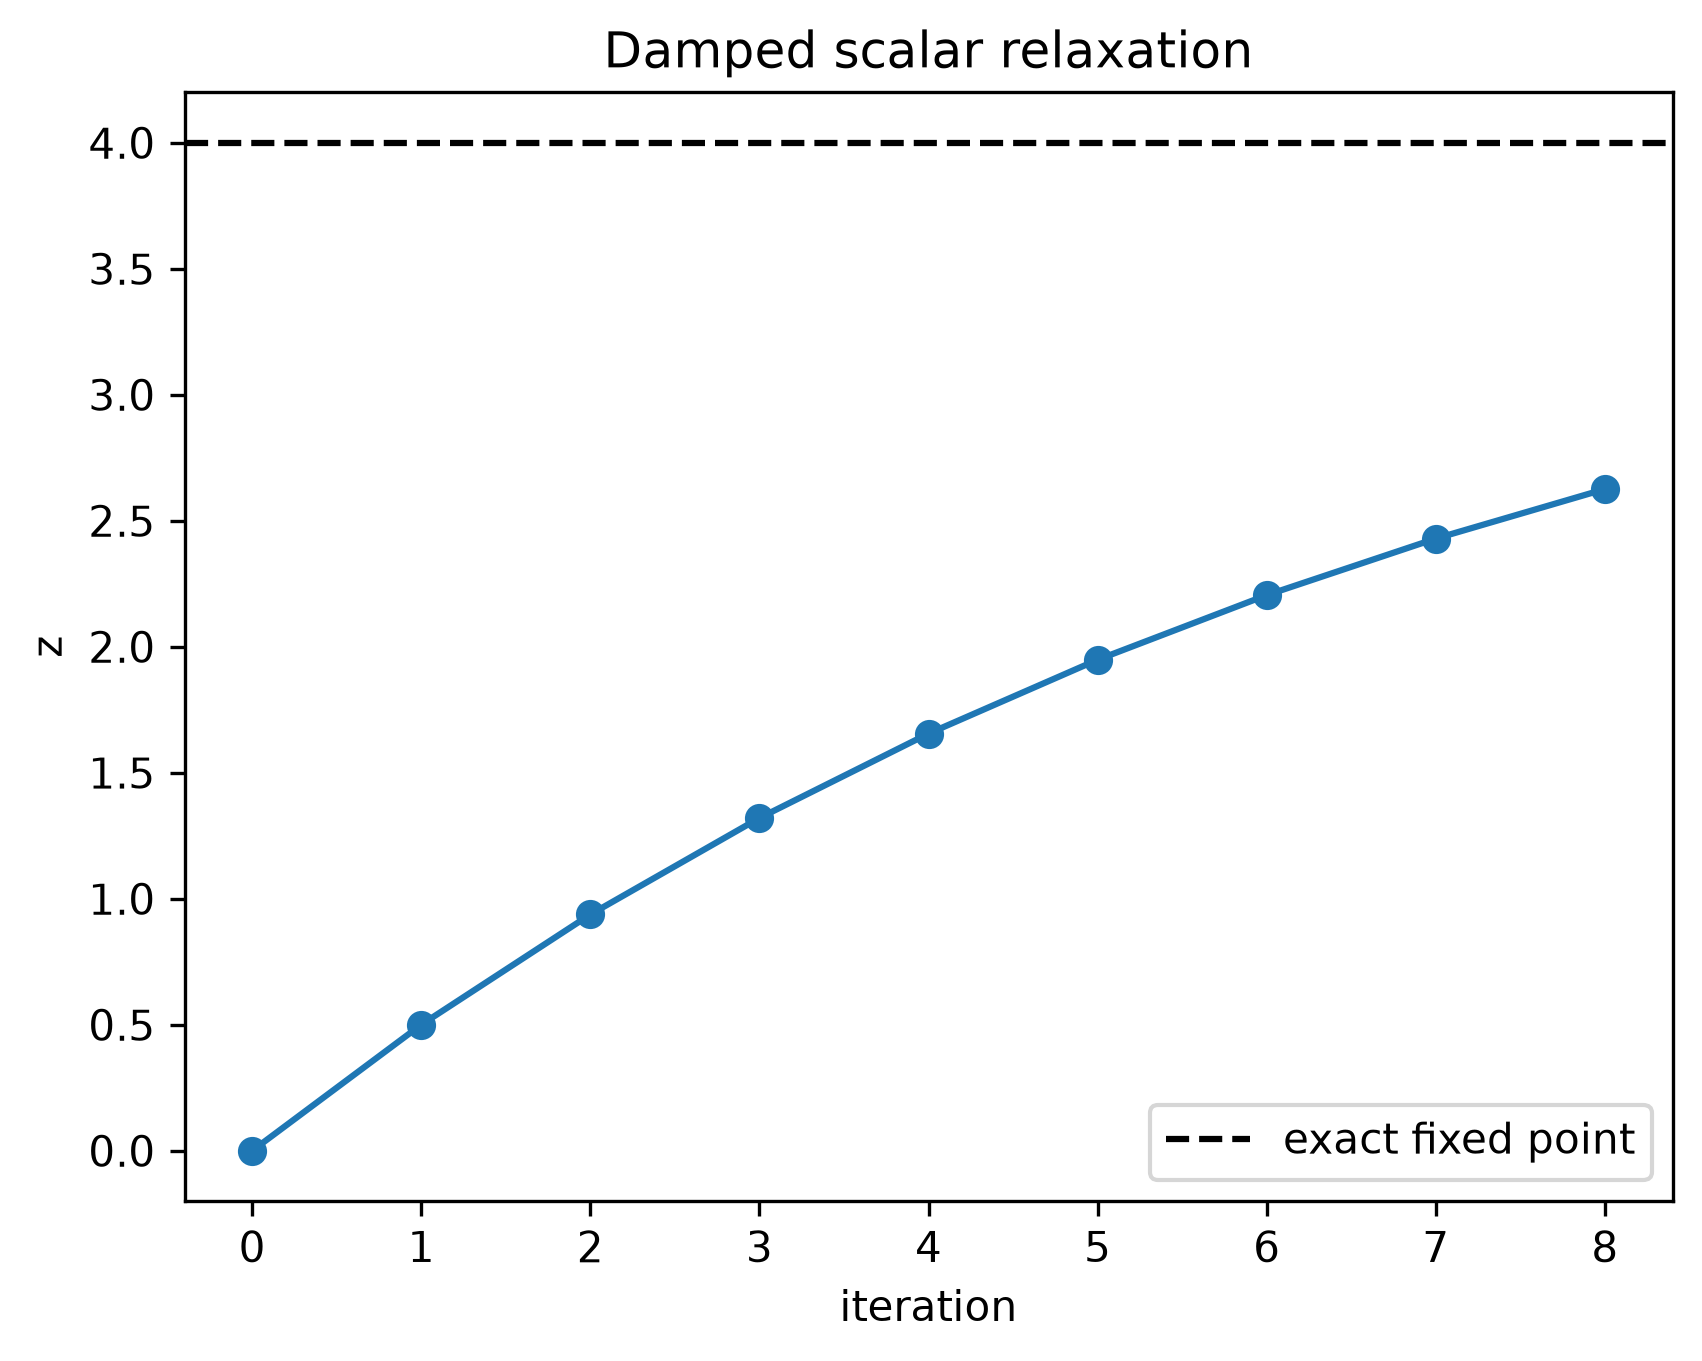

In [3]:

# 2. Scalar fixed points, residuals, and damping.
def f_scalar(z):
    return 0.5 * z + 2.0

# Solve z = 0.5 z + 2 by moving all z terms to the left:
# z - 0.5 z = 2, so 0.5 z = 2, so z = 4.
z_star_exact = 4.0
for test_z in [0.0, 3.0, 4.0]:
    residual_value = f_scalar(test_z) - test_z
    print("z =", test_z, "f(z)-z =", residual_value)

alpha = 0.25
z_current = 0.0
trajectory = [z_current]
for k in range(8):
    proposal = f_scalar(z_current)
    displacement = proposal - z_current
    z_current = z_current + alpha * displacement
    trajectory.append(z_current)
    print(f"k={k+1}: proposal={proposal:.6f}, displacement={displacement:.6f}, z={z_current:.6f}")

plt.plot(trajectory, marker="o")
plt.axhline(z_star_exact, linestyle="--", color="black", label="exact fixed point")
plt.xlabel("iteration")
plt.ylabel("z")
plt.title("Damped scalar relaxation")
plt.legend()
plt.show()


## 3. Finite differences and exact Jacobians


In [4]:

# 3. Finite differences and exact Jacobian for f(z)=tanh(Wz+s).
W_small = np.array([[0.2, -0.1],
                    [0.05, 0.25]])
s_small = np.array([0.4, -0.3])
z0_small = np.zeros(2)

def f_small_np(z):
    return np.tanh(W_small @ z + s_small)

J_fd = np_finite_difference_jacobian(f_small_np, z0_small, eps=1e-5)
J_exact = np_exact_tanh_affine_jacobian(W_small, z0_small, s_small)

print("preactivation Wz+s:", W_small @ z0_small + s_small)
print("diag entries 1-tanh(pre)^2:", 1.0 - np.tanh(s_small) ** 2)
print("finite-difference Jacobian:\n", J_fd)
print("exact Jacobian:\n", J_exact)
print("agreement ||J_fd-J_exact||_F:", np.linalg.norm(J_fd - J_exact))

# Show one central-difference column explicitly.
eps = 1e-3
e1 = np.array([1.0, 0.0])
column_1 = (f_small_np(z0_small + eps * e1) - f_small_np(z0_small - eps * e1)) / (2 * eps)
print("first Jacobian column from central difference:", column_1)
print("first exact column:", J_exact[:, 0])


preactivation Wz+s: [ 0.4 -0.3]
diag entries 1-tanh(pre)^2: [0.85563879 0.91513696]
finite-difference Jacobian:
 [[ 0.17112776 -0.08556388]
 [ 0.04575685  0.22878424]]
exact Jacobian:
 [[ 0.17112776 -0.08556388]
 [ 0.04575685  0.22878424]]
agreement ||J_fd-J_exact||_F: 2.2141979057820696e-12
first Jacobian column from central difference: [0.17112776 0.04575685]
first exact column: [0.17112776 0.04575685]


## 4. JVP and VJP in PyTorch


In [5]:

# 4. PyTorch JVP and VJP on the same small map.
W_t = torch.tensor(W_small)
s_t = torch.tensor(s_small)
z_t = torch.zeros(2, requires_grad=True)

def f_small_torch(z):
    return torch.tanh(W_t @ z + s_t)

J_full = torch_full_jacobian(f_small_torch, z_t.detach())
v_t = torch.tensor([1.0, -2.0])
_, Jv = torch_jvp(f_small_torch, z_t.detach(), v_t)
JTv = torch_vjp(f_small_torch, z_t.detach(), v_t)

print("full Jacobian:\n", J_full.detach().numpy())
print("J @ v from materialized J:", (J_full @ v_t).detach().numpy())
print("JVP from autograd:", Jv.detach().numpy())
print("J.T @ v from materialized J:", (J_full.T @ v_t).detach().numpy())
print("VJP from autograd:", JTv.detach().numpy())


full Jacobian:
 [[ 0.17112776 -0.08556388]
 [ 0.04575685  0.22878424]]
J @ v from materialized J: [ 0.34225551 -0.41181163]
JVP from autograd: [ 0.34225551 -0.41181163]
J.T @ v from materialized J: [ 0.07961406 -0.54313236]
VJP from autograd: [ 0.07961406 -0.54313236]


## 5. Graph locality and mean-field global context


In [6]:

# 5. Local graph aggregation and mean-field global context.
H = np.array([[2.0],
              [5.0]])
A_graph = np.array([[0.0, 1.0],
                    [1.0, 0.0]])
print("AH swaps the two node states:\n", A_graph @ H)

Y = np.array([[1.0, 0.0],
              [3.0, 2.0],
              [5.0, 4.0]])
Wg = np.array([[1.0, -1.0],
               [0.5, 0.25]])

# Start from the empirical mean definition.
mean_loop = np.zeros(Y.shape[1])
for j in range(Y.shape[0]):
    mean_loop = mean_loop + Y[j]
mean_loop = mean_loop / Y.shape[0]
print("mean from explicit sum:", mean_loop)

# Broadcast and mix.
global_loop = np.zeros((Y.shape[0], Wg.shape[0]))
for i in range(Y.shape[0]):
    global_loop[i] = mean_loop @ Wg.T

one = np.ones((Y.shape[0], 1))
P_global = one @ one.T / Y.shape[0]
global_matrix = P_global @ Y @ Wg.T
print("global term from loops:\n", global_loop)
print("global term from matrix formula:\n", global_matrix)
print("loop/matrix difference:", np.linalg.norm(global_loop - global_matrix))

# Permutation equivariance check: G(Pi Y) = Pi G(Y).
perm = np.array([2, 0, 1])
Pi = np.eye(3)[perm]
lhs = P_global @ (Pi @ Y) @ Wg.T
rhs = Pi @ (P_global @ Y @ Wg.T)
print("permutation equivariance error:", np.linalg.norm(lhs - rhs))


AH swaps the two node states:
 [[5.]
 [2.]]
mean from explicit sum: [3. 2.]
global term from loops:
 [[1. 2.]
 [1. 2.]
 [1. 2.]]
global term from matrix formula:
 [[1. 2.]
 [1. 2.]
 [1. 2.]]
loop/matrix difference: 0.0
permutation equivariance error: 8.599750569898517e-16


## 6. Probability probes and physical relaxation


Jv: [-1. -1.]
single Hutchinson probe ||Jv||^2: 2.0
exact ||J||_F^2: 6.0
average over 1000 Rademacher probes: 5.984
relaxed state: [ 1.99244421 -1.33315452]
last vector-field norm: 0.004726251005474485


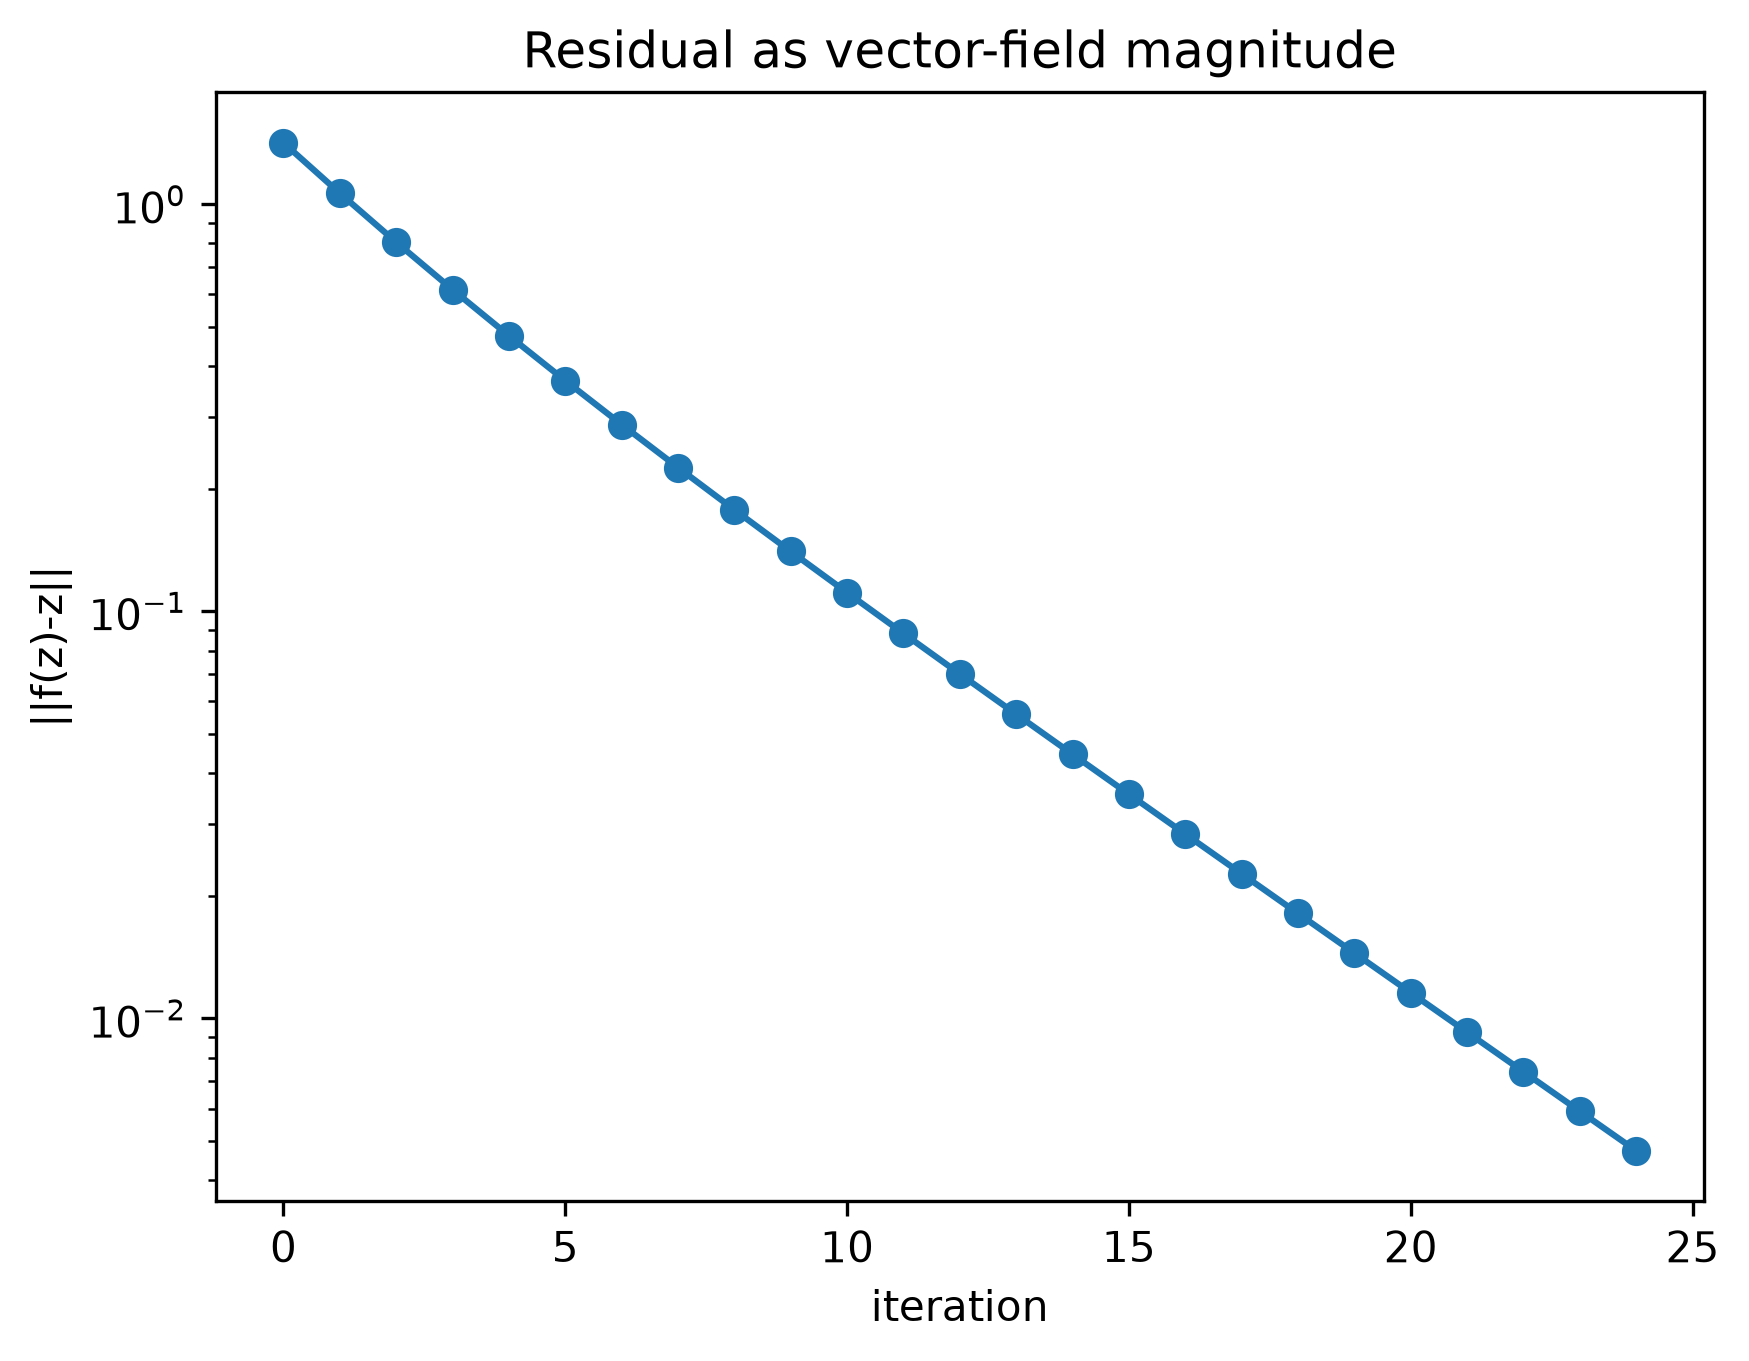

In [7]:

# 6. Hutchinson probe and physical relaxation.
J = np.array([[1.0, 2.0],
              [0.0, 1.0]])
v_probe = np.array([1.0, -1.0])
Jv = J @ v_probe
print("Jv:", Jv)
print("single Hutchinson probe ||Jv||^2:", float(Jv @ Jv))
print("exact ||J||_F^2:", float(np.sum(J ** 2)))

rng = np.random.default_rng(7)
estimates = []
for _ in range(1000):
    v = rng.choice([-1.0, 1.0], size=2)
    estimates.append(np.sum((J @ v) ** 2))
print("average over 1000 Rademacher probes:", float(np.mean(estimates)))

# Physical relaxation: z_{k+1}=z_k+alpha(f(z_k)-z_k).
def f_relax(z):
    return np.array([0.5 * z[0] + 1.0, 0.25 * z[1] - 1.0])

z = np.zeros(2)
alpha = 0.4
residuals = []
for _ in range(25):
    field = f_relax(z) - z
    residuals.append(np.linalg.norm(field))
    z = z + alpha * field
print("relaxed state:", z)
print("last vector-field norm:", residuals[-1])
plt.semilogy(residuals, marker="o")
plt.xlabel("iteration")
plt.ylabel("||f(z)-z||")
plt.title("Residual as vector-field magnitude")
plt.show()


## 7. Implicit adjoint solve


In [8]:

# 7. One adjoint solve by hand and by NumPy.
J = np.array([[0.2, 0.1],
              [0.0, 0.3]])
g = np.array([1.0, 2.0])
A_adj = np.eye(2) - J.T
lam = np.linalg.solve(A_adj, g)

print("I-J.T:\n", A_adj)
print("lambda:", lam)
print("check (I-J.T) lambda:", A_adj @ lam)

# If df/dtheta has two parameter columns, lambda^T df/dtheta gives the gradient.
df_dtheta = np.array([[1.0, 0.0],
                      [2.0, -1.0]])
grad_theta = lam @ df_dtheta
print("lambda^T df/dtheta:", grad_theta)


I-J.T:
 [[ 0.8  0. ]
 [-0.1  0.7]]
lambda: [1.25       3.03571429]
check (I-J.T) lambda: [1. 2.]
lambda^T df/dtheta: [ 7.32142857 -3.03571429]


## 8. Exercise-linked checks


In [9]:

# 8. Tiny checks tied to Chapter 0 exercises.
print("P0.E3 fixed point for f(z)=0.25z+3:", 3.0 / (1.0 - 0.25))

def square(z):
    return z ** 2
eps = 0.1
central = (square(2.0 + eps) - square(2.0 - eps)) / (2 * eps)
print("P0.E4 central difference for z^2 at z=2:", central)

T = np.array([[0.2, 0.0],
              [0.0, 0.5]])
s = np.array([1.0, 2.0])
print("P0.M3 (I-T)^-1 s:", np.linalg.solve(np.eye(2) - T, s))

# Mean-field Jacobian action:
# If G(Y)=P Y Wg.T, then dG[V]=P V Wg.T.
V = np.random.randn(*Y.shape)
dG = P_global @ V @ Wg.T
eps = 1e-6
finite_dG = (P_global @ (Y + eps * V) @ Wg.T - P_global @ Y @ Wg.T) / eps
print("mean-field Jacobian action agreement:", np.linalg.norm(dG - finite_dG))


P0.E3 fixed point for f(z)=0.25z+3: 4.0
P0.E4 central difference for z^2 at z=2: 4.000000000000001
P0.M3 (I-T)^-1 s: [1.25 4.  ]
mean-field Jacobian action agreement: 6.940972130704194e-10


## Chapter 0 executable summary

Chapter 0 is the math-and-physics foundation in executable form. Every later chapter specializes these same ideas to DEQ, MDEQ, SILVA, PDE, graph, distributional, or algorithmic equilibrium settings.


## From 00 Math Physics Preliminaries to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [10]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 1.621736402640195e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [11]:
notebook_reproduction_record = {
    "notebook": '00_math_physics_preliminaries.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '00_math_physics_preliminaries.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **implicit dynamics factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [12]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('implicit dynamics factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


implicit dynamics factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 7.168e-09 | 1.792e-09 | 1.2500 | 0.000e+00
0.45 |  23 | 8.218e-09 | 6.723e-09 | 1.8182 | 0.000e+00
0.70 |  50 | 8.992e-09 | 2.098e-08 | 3.3333 | 0.000e+00
0.85 | 108 | 9.815e-09 | 5.562e-08 | 6.6667 | 0.000e+00


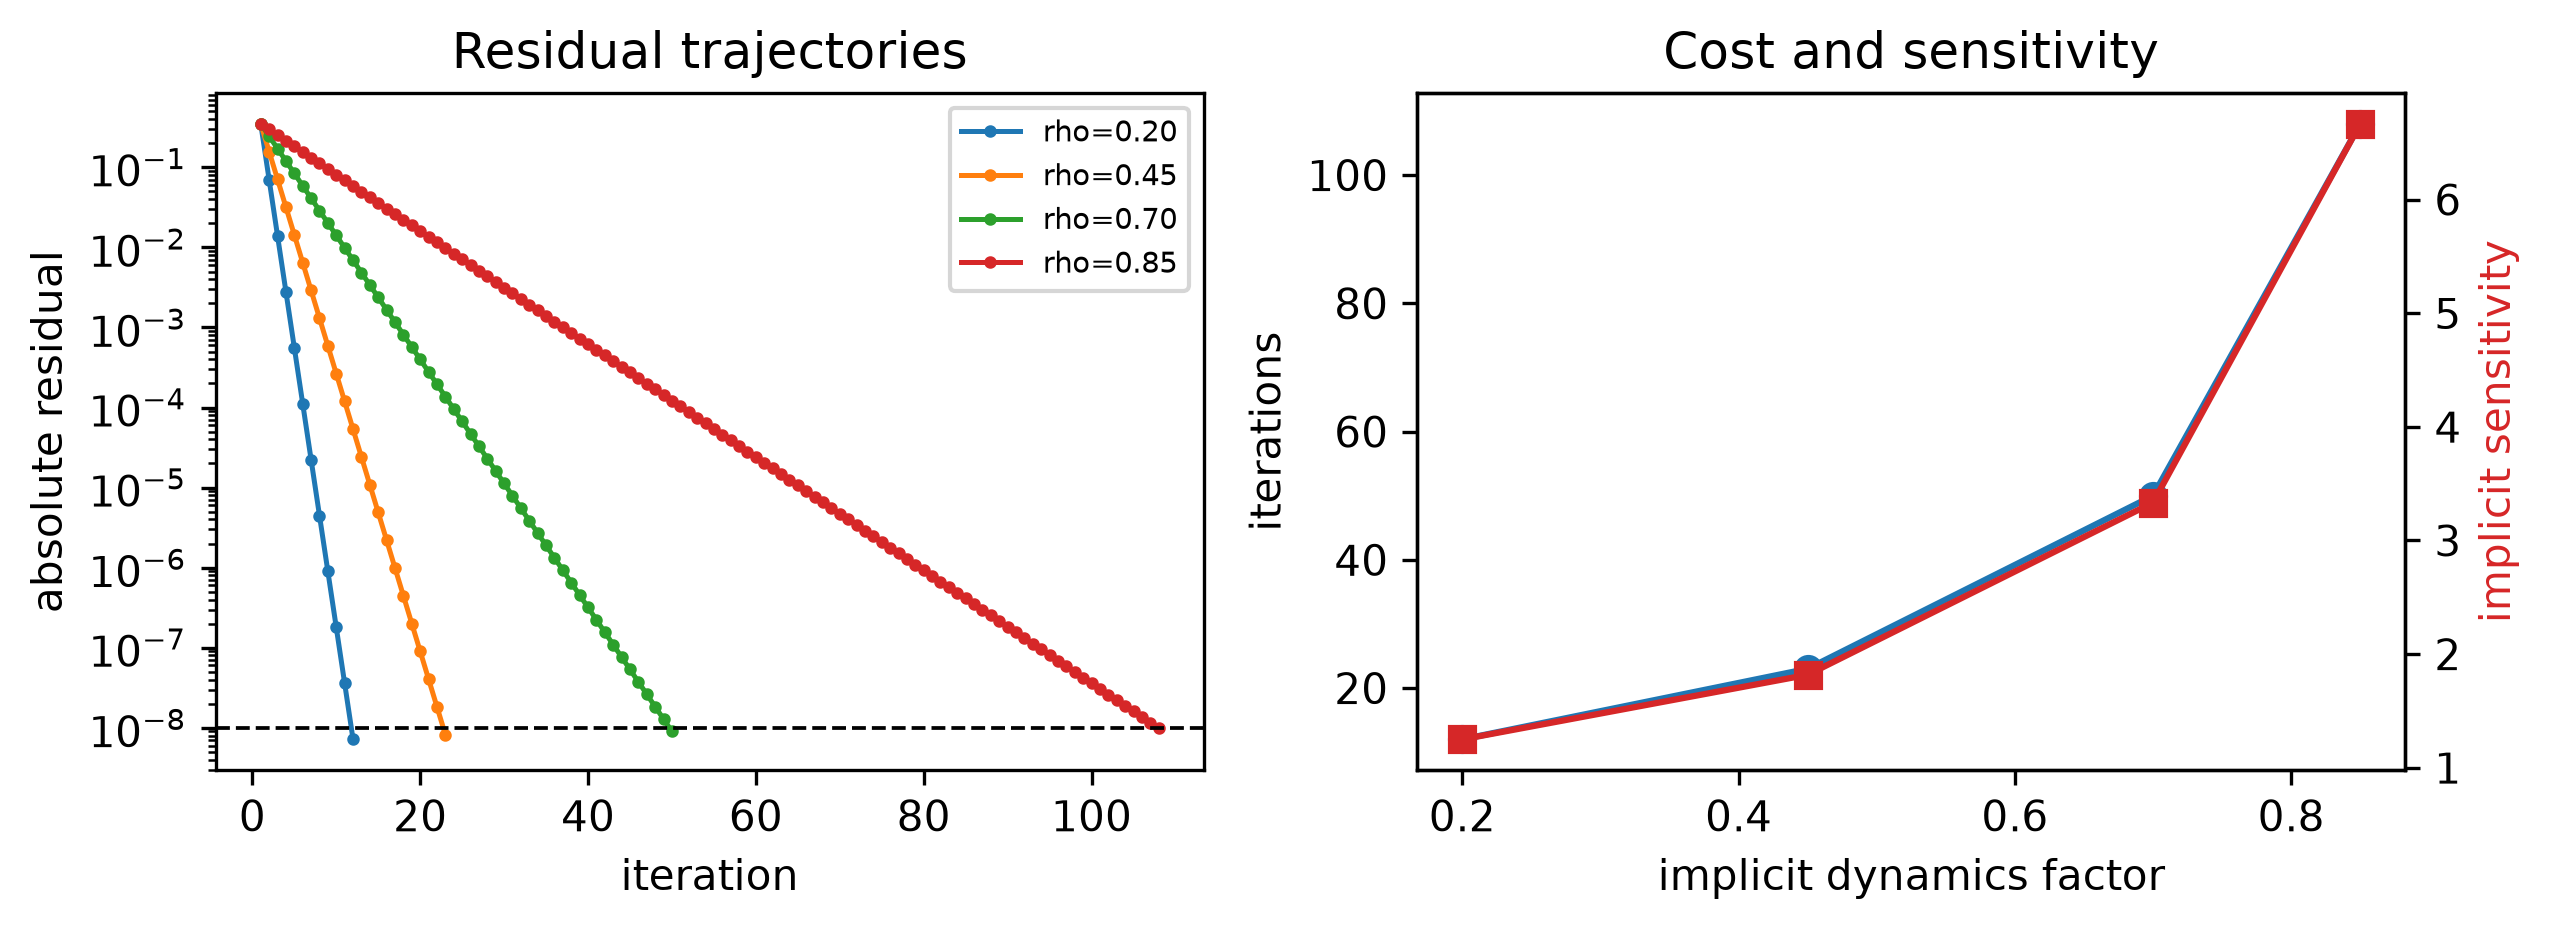

In [13]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('implicit dynamics factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the implicit dynamics factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.
